# import the library

In [ ]:
import torch
import torch.nn as nn
import math

from torchvision.datasets import FashionMNIST
from torchvision import transforms
from torch.utils.data import dataloader
from torch.utils.tensorboard import SummaryWriter 
import matplotlib.pyplot as plt



## Preprocess the dataset

In [3]:
# using transform from pytorch 

train_transform =transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5,0.5),
])

train_set= FashionMNIST(root='./Data',
            train=True,
            download=True,
            transform=train_transform)

train_batcher=dataloader.DataLoader(train_set,
                                   32,
                                   shuffle=True)

## Exploring the shapes of the data

In [3]:
for x,y in train_batcher:
    print(x.shape) # (b,c,h,w)
    break

torch.Size([32, 1, 28, 28])


In [4]:
# this class used to expresses each time step

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t,device='cuda'):
        # t shape: (batch,)
        device = t.device

        half_dim = self.dim // 2
        emb_scale = math.log(10000) / (half_dim - 1)

        emb = torch.exp(torch.arange(half_dim, device=device) * -emb_scale)
        emb = t[:, None] * emb[None, :]

        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return emb

## Model-building

In [5]:
# double conv class for the U-net
class Double_convolution(nn.Module):
    def __init__(self, in_channel,out_channel,time_em=128):
        super().__init__()

        self.conv1=nn.Sequential(
            nn.Conv2d(in_channels=in_channel,out_channels=out_channel,kernel_size=3,padding=1),
            nn.GroupNorm(num_groups=8,num_channels=out_channel),
            nn.ReLU(inplace=True),
            )
        
        self.conv2=nn.Sequential(
            nn.Conv2d(in_channels=out_channel,out_channels=out_channel,kernel_size=3,padding=1),
            nn.GroupNorm(num_groups=8,num_channels=out_channel),
            nn.ReLU(inplace=True)
            )
        
        self.time_mlp=nn.Sequential(
                                    TimeEmbedding(time_em),
                                    nn.Linear(time_em,time_em),
                                    nn.ReLU(inplace=True),
                                    nn.Linear(time_em,out_channel)
                                    )
        
    def forward(self,x,t):

        out= self.conv1(x)
        out_t=self.time_mlp(t)[:,:,None,None]

        out=out+out_t
        out=self.conv2(out)

        return out
    
# Unet- Down sample used to extract feature from the input (noise)
class Down_sample(nn.Module):
    def __init__(self,in_channel,out_channel):
        super().__init__()
        self.conv=Double_convolution(in_channel,out_channel)
        self.pool=nn.MaxPool2d(kernel_size=(2,2))
        
        
    def forward(self,x,t):
        down_s=self.conv(x,t)
        out=self.pool(down_s)
        return down_s , out
    
# takes the extracted feature and rebuilt the image
class Up_sample(nn.Module):
    def __init__(self,in_channel,out_channel):
        super().__init__()
        self.up=nn.ConvTranspose2d(in_channel,in_channel//2,kernel_size=(3,3),stride=2)
        self.conv=Double_convolution(in_channel,out_channel)


    
    def forward(self,res,x,t):
        up_out=self.up(x)
        _,_,h_res,_=res.shape
        _,_,h_x,_=up_out.shape
        
        h_min=torch.min(torch.tensor([h_res,h_x]))

        out=torch.concat([res[:,:,:h_min,:h_min],up_out[:,:,:h_min,:h_min]],dim=1)
        out=self.conv(out,t)
        return out

# building the U-net
class Unet(nn.Module):
    def __init__(self,input_channel,target_channel):
        super().__init__()

        self.down_sample=Down_sample(input_channel,64) 
        self.down_sample2=Down_sample(64,128)     
        self.down_sample3=Down_sample(128,256)     
        
        self.bottelneck=Double_convolution(256,512)

        self.up_saple=Up_sample(512,256)
        self.up_saple2=Up_sample(256,128)     
        self.up_saple3=Up_sample(128,64)

        self.channel_down=nn.Conv2d(64,target_channel,kernel_size=(1,1))

    def forward(self,x,t):
        # down sample
        res,out=self.down_sample(x,t)
        res2,out=self.down_sample2(out,t)     
        res3,out=self.down_sample3(out,t)
        # bottle-neck
        out=self.bottelneck(out,t)
        # up sample
        out=self.up_saple(res3,out,t)
        out=self.up_saple2(res2,out,t)
        out=self.up_saple3(res,out,t)

        out=self.channel_down(out)



        return out     




In [6]:
class Image_noiser(nn.Module):
    def __init__(self,beta_start=0.0001,beta_end=0.02,time=1000,device='cuda'):
        super().__init__()

        self.beta=torch.linspace(beta_start,
                                 beta_end,
                                 time,
                                 device=device)

        self.alpha = 1 - self.beta

        self.alpha_hat = self.alpha.cumprod(dim=0)
    
    def noise_image(self,image,time):

        gussian_noise=torch.randn_like(image,device=image.device)

        ## Xt = sqrt(alpha_bar)*Xt-1 + sqrt(alpha_bar-1)*E    E => is the gussian noise
        
        image_after_noise=torch.sqrt(self.alpha_hat[time])[:,None,None,None]*image + torch.sqrt(1-self.alpha_hat[time])[:,None,None,None] * gussian_noise

        return image_after_noise , gussian_noise
    
    def sample_image(self,model,num_samples,device):
    #  generate image by reversing the process of adding noise
     model.eval()
     x_t=torch.randn(num_samples,1,28,28).to(device=device)
     time_list=torch.ones(num_samples,).int().to(device)
     noise_zeros=torch.zeros_like(x_t)


     for time in reversed(range(1000)):
        time=time_list*time

        alpha=self.alpha[time][:,None,None,None]
        alpha_hat_t=self.alpha_hat[time][:,None,None,None]
        beta=self.beta[time][:,None,None,None]

        if time[0] == 0 :
         
         noise=noise_zeros
           
        else:
          
         noise=torch.randn_like(x_t)

        time=time.float()
        predicted_noise=model(x_t,time)
        # the equation of reverse process
        x_t=1/alpha.sqrt()*\
            (x_t-((1-alpha)/(1-alpha_hat_t).sqrt()*predicted_noise))\
            +beta.sqrt()*noise
        
     model.train()

     return ( x_t.clamp(-1,1) + 1 ) / 2



            




# Initialize hyper-params of the model

In [ ]:
# check if my poor gpu is not dead
device='cuda' if torch.cuda.is_available() else 'cpu'
ima_noiser=Image_noiser()
writer=SummaryWriter(log_dir='Logs/test2_fashion_mnist')

model=Unet(input_channel=1,target_channel=1).to(device)
# using mse just for now may in future i will use l1 along with mse 
cr=nn.MSELoss()
optim=torch.optim.AdamW(model.parameters(),
                        lr=1e-4,
                        weight_decay=1e-4)
epochs=100
total_batches=len(train_batcher)

## The Training

In [ ]:

total_steps=0
for e in range(epochs):
 avg_loss=0
 for step, (x,_) in enumerate(train_batcher):
     optim.zero_grad()
     model.zero_grad()

     x=x.to(device)
     t=torch.randint(0,1000,size=(x.shape[0],),device=device)

     image_aftern,guasian_n=ima_noiser.noise_image(x,t)
     t1=t.float()
     out =model(image_aftern,t1)

    #  calc loss
     loss= cr(out,guasian_n)
     avg_loss+=loss.item()
    #  calc gradiant and update the weights
     loss.backward()
     nn.utils.clip_grad_norm_(model.parameters(),max_norm=1)
     optim.step()
      
         
     if step % 20 ==0:
      total_steps+=1
      # print the loss each 20 step and record it in tensorboard
      print(f'[{e}:{epochs}][{step}] ---------> loss {loss.item():.4f}')
      writer.add_scalar('Loss over each 20 steps',loss,total_steps)

      # Record the gradiant help findout if the gradiant are vanishing or exploding 
      total_grad_norm=0
      for param in model.parameters():
          if param.grad !=None:
              grad_norm=param.grad.norm(p=2)
              total_grad_norm+=grad_norm**2
              total_grad_norm+=total_grad_norm
              total_grad_norm=total_grad_norm.sqrt()

      writer.add_scalar("Grad norm",total_grad_norm.item(),total_steps)

      # test the model each epoch
 with torch.inference_mode():    
   images=ima_noiser.sample_image(model,2,device)
   images=images.detach().cpu()
   writer.add_images("Test_images",images,e)
 
# record the avgloss each epoch
 avg_loss=avg_loss/total_batches
 print(f'[{e}:{epochs}]---------> avg_loss {avg_loss:.4f}')
 writer.add_scalar('AVG Loss',avg_loss,e)

 torch.cuda.empty_cache() # may help ):
 
writer.close()





 

## Saving the model

In [ ]:
# torch.save(model,"ddpm_fashion_mnist.pt")

## Loading the model

In [9]:
model=torch.load("ddpm_fashion_mnist.pt",device,weights_only=False)

## Generate some sample

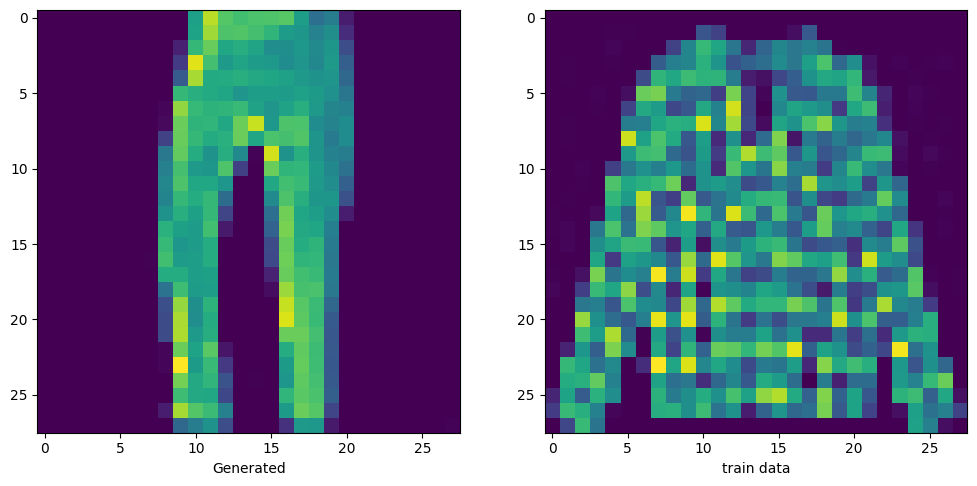

In [ ]:
torch.cuda.empty_cache() # may help ): 

fig = plt.figure(figsize=(12,6))
original_image=None
# just to take one example
for x,y in train_batcher:
    original_image=x[0].detach().cpu().numpy().reshape(28,28)
    break

plt.subplot(1,2,1)
image=ima_noiser.sample_image(model,1,device)
plt.imshow(image.detach().cpu().numpy().reshape(28,28))
plt.xlabel("Generated")

plt.subplot(1,2,2)
plt.imshow(original_image)
plt.xlabel("train data")

plt.show()

